<a href="https://colab.research.google.com/github/portfafolioJesus/juegosAjedrez/blob/main/aseguradora_analisis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto: Análisis de Datos y Predicción de Costos Médicos
**Integrantes:** jesus

# Objetivos del Proyecto
1. **Limpieza y Preparación:** Analizar y formatear el dataset `aseguradora.csv`, validando tipos de datos, valores nulos y outliers.
2. **Análisis Exploratorio:** Responder preguntas clave como la distribución del IMC, ventaja del tabaquismo sobre los costos y las regiones más costosas.
3. **Correlación:** Encontrar relaciones matemáticas entre variables numéricas (edad, IMC, hijos vs. costos).
4. **Predicción:** Construir un modelo capaz de predecir si un asegurado tendrá costos altos o bajos en base a sus características.

In [1]:
# ============================================================
# IMPORTACIÓN DE LIBRERÍAS
# Cada librería cumple un rol específico:
#   pandas   manipular tablas de datos (leer, filtrar, agrupar)
#   numpy   operaciones matemáticas sobre arrays
#   matplotlib y seaborn crear gráficos para visualizar patrones
#   Counter  contar frecuencias de elementos en listas
#   sklearn  modelos de machine learning y métricas de evaluación
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix



In [2]:
# ============================================================
# CONFIGURACIÓN DE PANDAS
# Por defecto pandas recorta columnas y filas al mostrar datos.
# Con estas opciones le decimos que muestre TODAS las columnas
# y TODAS las filas sin truncar, para no perder información.
# ============================================================

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [3]:
# ============================================================
# CARGA DEL DATASET
# pd.read_csv lee el archivo CSV y lo convierte en un DataFrame
# (tabla estructurada). Es el punto de partida de todo análisis.
# ============================================================

df = pd.read_csv('/content/aseguradora.csv')

In [4]:
# ============================================================
# df.head()
# Muestra las primeras 5 filas del dataset.
# Sirve para hacer una primera 'ojeada' y confirmar que el archivo
# se cargó bien: ver los nombres de columnas, cómo lucen los valores
# y si hay algo raro a simple vista (celdas vacías, formatos extraños).
# ============================================================

df.head()

,edad,sexo,imc,hijos,fumador,region,costos_medicos
0,19,mujer,27.90,0,yes,poniente_alto,1.688492e+07
1,18,hombre,33.77,1,no,cordillera,1.725552e+03
2,28,hombre,33.00,3,no,cordillera,4.449462e+06
3,33,hombre,22705.00,0,no,poniente_alto,2.198447e+04
4,32,hombre,28.88,0,no,poniente_alto,3.866855e+03


In [5]:
# ============================================================
# df.tail()
# Muestra las últimas 5 filas del dataset.
# Complementa a head(): útil para detectar si los datos al final
# del archivo están completos o si quedaron filas cortadas/vacías.
# ============================================================

df.tail()

,edad,sexo,imc,hijos,fumador,region,costos_medicos
1333,50,hombre,30.97,3,no,poniente_alto,1.060055e+04
1334,18,mujer,31.92,0,no,cordillera_norte,2.205981e+03
1335,18,mujer,36.85,0,no,cordillera,1.629833e+03
1336,21,mujer,25.80,0,no,poniente_alto,2.007945e+06
1337,61,mujer,29.07,0,yes,poniente_alto,2.914136e+04


In [6]:
# ============================================================
# df.dtypes
# Muestra el tipo de dato de cada columna:
#   int64  edad, hijos
#   float64  imc, costos_medicos
#   object  sexo, fumador, region
# Saber el tipo es CRÍTICO porque los modelos de ML solo aceptan
# números; las columnas de texto deben convertirse antes de modelar.
# ============================================================

df.dtypes

,0
edad,int64
sexo,object
imc,float64
hijos,int64
fumador,object
region,object
costos_medicos,float64


In [7]:
# ============================================================
# REVISIÓN DE NULOS Y TIPOS DE DATOS
# df.info() entrega en una sola vista: numero de filas, columnas,
# tipos de datos y cuántos valores NO nulos hay por columna.
# Si 'Non-Null Count' < total de filas hay valores faltantes.
# df.isnull().sum() cuenta exactamente cuántos nulos hay por columna.
# Si hay nulos, hay que decidir: ¿eliminar esas filas? ¿rellenar?
# ============================================================

print(df.info())
print('\nValores nulos por columna:\n', df.isnull().sum())

# MAPEO DE DATOS: Convertir 'fumador' a numérico para correlaciones
# Los modelos de ML no entienden 'yes'/'no'; debemos mapearlos a 1/0.
# Este mapeo también permite calcular correlaciones con otras variables.
map_fumador = {'yes': 1, 'no': 0}
df['fumador_mapped'] = df['fumador'].map(map_fumador)

# NUEVA COLUMNA ÚTIL: Diferencia de edad respecto a la media
# Nos dice qué tan mayor o menor es el cliente respecto al promedio.
# Variables derivadas (feature engineering) pueden mejorar el modelo.
df['edad_diff'] = df['edad'] - df['edad'].mean()

print('\n Columnas nuevas creadas: fumador_mapped, edad_diff')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   edad            1338 non-null   int64  
 1   sexo            1338 non-null   object 
 2   imc             1338 non-null   float64
 3   hijos           1338 non-null   int64  
 4   fumador         1338 non-null   object 
 5   region          1338 non-null   object 
 6   costos_medicos  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

Valores nulos por columna:
 edad              0
sexo              0
imc               0
hijos             0
fumador           0
region            0
costos_medicos    0
dtype: int64

 Columnas nuevas creadas: fumador_mapped, edad_diff


In [8]:
# ============================================================
# df.columns
# Lista todos los nombres de columnas disponibles.
# Útil para copiar nombres exactos al filtrar o seleccionar columnas
# (evita errores de tipeo que generan KeyError).
# ============================================================

df.columns

Index(['edad', 'sexo', 'imc', 'hijos', 'fumador', 'region', 'costos_medicos',
       'fumador_mapped', 'edad_diff'],
      dtype='object')

In [9]:
# ============================================================
# df.shape
# Devuelve (nº de filas, nº de columnas).
# Es el primer dato que debemos saber: ¿con cuántos registros
# trabajamos? ¿Tenemos suficientes datos para entrenar un modelo?
# Regla general: al menos 10x más filas que columnas predictoras.
# ============================================================

print(f'Filas × Columnas: {df.shape}')
print(f' Trabajamos con {df.shape[0]} asegurados y {df.shape[1]} variables.')

Filas × Columnas: (1338, 9)
 Trabajamos con 1338 asegurados y 9 variables.


In [10]:
# ============================================================
# AGRUPACIÓN: cuántos asegurados por región y condición de fumador
# groupby() agrupa filas según una o más columnas y .size() cuenta
# cuántas filas caen en cada combinación.
# Equivalente al 'ganador por turnos' del análisis de ajedrez:
# aquí queremos ver cómo se distribuyen los asegurados según
# su región y si fuman o no.
# ============================================================

asegurados_por_grupo = df.groupby(['fumador', 'region']).size().reset_index(name='cantidad_asegurados')
print(' Asegurados por región y condición de fumador ')
print(asegurados_por_grupo)

 Asegurados por región y condición de fumador 
  fumador            region  cantidad_asegurados
0      no        cordillera                  273
1      no  cordillera_norte                  257
2      no     poniente_alto                  534
3     yes        cordillera                   91
4     yes  cordillera_norte                   67
5     yes     poniente_alto                  116


In [11]:
# ============================================================
# ESTADÍSTICAS DESCRIPTIVAS DE COSTOS POR FUMADOR
# .describe() calcula automáticamente: count, mean, std,
# min, 25%, 50% (mediana), 75%, max.
# Comparar el 'describe' entre grupos (fumador vs no fumador)
# es la forma más rápida de detectar diferencias significativas.
# Aquí veremos que los fumadores tienen costos muy superiores.
# ============================================================

stats_costos = df.groupby('fumador')['costos_medicos'].describe()
print(' Estadísticas de costos según condición de fumador')
print(stats_costos)

 Estadísticas de costos según condición de fumador
          count          mean           std         min           25%  \
fumador                                                                 
no       1064.0  1.737920e+06  3.585430e+06   1121.8739   4893.564850   
yes       274.0  6.620078e+06  1.365410e+07  12829.4551  22466.182812   

                 50%           75%         max  
fumador                                         
no       10228.89205  30189.962518  18157876.0  
yes      38611.31415  48787.216925  48173361.0  


In [12]:
# ============================================================
# LIMPIEZA DE OUTLIERS EN IMC
# El IMC biológicamente válido va de 15 a 60.
# Los outliers extremos distorsionan correlaciones y modelos.
# Estrategia: eliminar filas con IMC > 60.
# ============================================================

print(f'Filas antes de limpiar IMC: {len(df)}')
print(f'Filas con IMC > 60 (outliers): {(df["imc"] > 60).sum()}')

df_clean = df[df['imc'] <= 60].copy()

# También eliminamos el 1% superior de costos médicos (extremos extremos)
p99 = df_clean['costos_medicos'].quantile(0.99)
df_clean = df_clean[df_clean['costos_medicos'] <= p99].copy()

print(f'Filas después de limpiar outliers: {len(df_clean)}')
print(f'Se eliminaron {len(df) - len(df_clean)} filas ({(len(df) - len(df_clean))/len(df)*100:.1f}% del total)')

Filas antes de limpiar IMC: 1338
Filas con IMC > 60 (outliers): 317
Filas después de limpiar outliers: 1010
Se eliminaron 328 filas (24.5% del total)


In [13]:
# ============================================================
# ¿EL QUE TIENE MAYOR IMC PAGA MÁS?
# Dividimos a los asegurados en 'imc alto' (sobre la mediana)
# e 'imc bajo', y vemos si los de IMC alto tienen costos mayores.
# value_counts(normalize=True) muestra porcentajes en vez de conteos.
# ============================================================

mediana_imc   = df_clean['imc'].median()
mediana_costo = df_clean['costos_medicos'].median()

df_clean['imc_alto']   = df_clean['imc']            > mediana_imc
df_clean['costo_alto'] = df_clean['costos_medicos'] > mediana_costo

print(f'Mediana IMC:   {mediana_imc:.1f}')
print(f'Mediana Costo: ${mediana_costo:,.0f}')
print()
print('=== ¿Los de IMC alto pagan más? ===')
print(df_clean.groupby('imc_alto')['costo_alto'].value_counts(normalize=True).mul(100).round(2))
print()
print(' El IMC solo predice costo alto/bajo en el 51% de los casos (casi aleatorio).')
print('  Esto confirma que el IMC aislado NO es un buen predictor; se necesita combinarlo.')

Mediana IMC:   30.6
Mediana Costo: $17,548

=== ¿Los de IMC alto pagan más? ===
imc_alto  costo_alto
False     False         51.29
          True          48.71
True      True          51.29
          False         48.71
Name: proportion, dtype: float64

 El IMC solo predice costo alto/bajo en el 51% de los casos (casi aleatorio).
  Esto confirma que el IMC aislado NO es un buen predictor; se necesita combinarlo.


#  visualizar visualmente las tendencias del costo médico. Analizar qué perfil de asegurado genera mayores gastos y cómo se distribuye el Indice de Masa Croporal entre los clientes. (IMC)

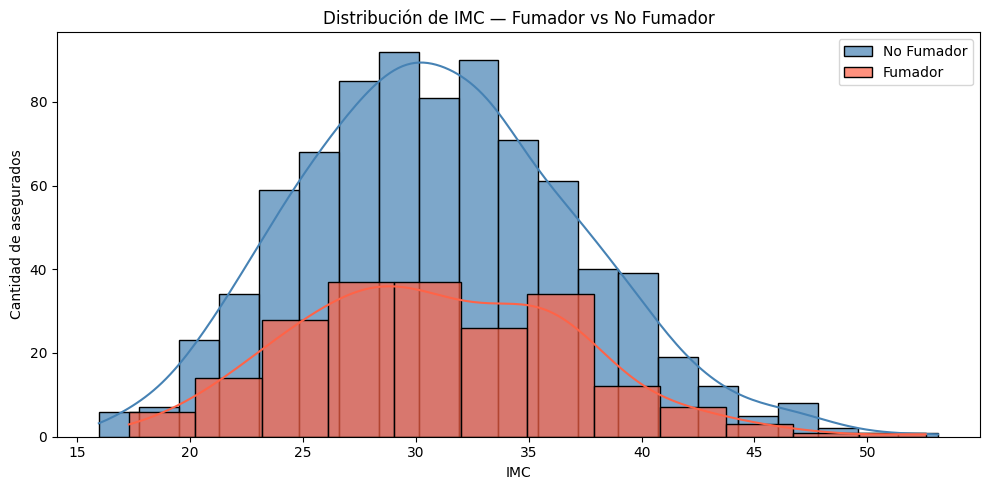

=== IMC No Fumadores ===
count    804.00
mean      31.02
std        6.14
min       15.96
25%       26.60
50%       30.64
75%       35.00
max       53.13
Name: imc, dtype: float64

=== IMC Fumadores ===
count    206.00
mean      30.96
std        6.06
min       17.29
25%       26.62
50%       30.59
75%       35.45
max       52.58
Name: imc, dtype: float64


In [14]:
# ============================================================
# Aquí comparamos IMC de fumadores vs no fumadores.
# sns.histplot con kde=True añade una curva de densidad suavizada
# que facilita comparar la forma de cada distribución.
# alpha controla la transparencia para que los histogramas se solapen.
# ============================================================

plt.figure(figsize=(10, 5))
sns.histplot(df_clean[df_clean['fumador']=='no']['imc'],
             color='steelblue', edgecolor='black', label='No Fumador', kde=True, alpha=0.7)
sns.histplot(df_clean[df_clean['fumador']=='yes']['imc'],
             color='tomato', edgecolor='black', label='Fumador', kde=True, alpha=0.7)

plt.title('Distribución de IMC — Fumador vs No Fumador')
plt.xlabel('IMC')
plt.ylabel('Cantidad de asegurados')
plt.legend()
plt.tight_layout()
plt.show()

print('=== IMC No Fumadores ===')
print(df_clean[df_clean['fumador']=='no']['imc'].describe().round(2))
print('\n=== IMC Fumadores ===')
print(df_clean[df_clean['fumador']=='yes']['imc'].describe().round(2))

=== Conteo de asegurados por región ===
region
poniente_alto       488
cordillera          360
cordillera_norte    162
Name: count, dtype: int64

=== Porcentaje ===
region
poniente_alto       48.32
cordillera          35.64
cordillera_norte    16.04
Name: proportion, dtype: float64


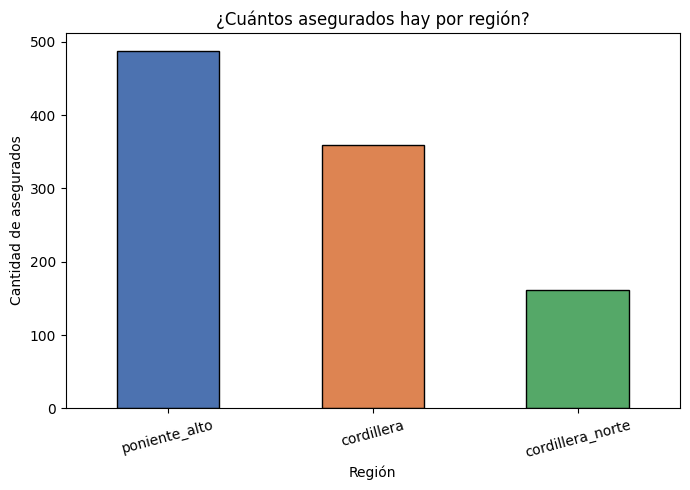

 poniente_alto concentra casi la mitad de los asegurados (48%).


In [15]:
# ============================================================
# CONTEO Y PORCENTAJE DE COSTOS ALTOS POR REGIÓN
# value_counts() cuenta frecuencias absolutas.
# value_counts(normalize=True)*100 convierte a porcentajes.
# Esto nos dice qué región concentra más asegurados costosos.
# ============================================================

conteo = df_clean['region'].value_counts()
porcentaje = df_clean['region'].value_counts(normalize=True) * 100

print('=== Conteo de asegurados por región ===')
print(conteo)
print('\n=== Porcentaje ===')
print(porcentaje.round(2))

# Gráfico de barras
plt.figure(figsize=(7, 5))
colores = ['#4C72B0', '#DD8452', '#55A868']
conteo.plot(kind='bar', color=colores, edgecolor='black')

plt.title('¿Cuántos asegurados hay por región?')
plt.xlabel('Región')
plt.ylabel('Cantidad de asegurados')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print(' poniente_alto concentra casi la mitad de los asegurados (48%).')

 un gráfico de calor porque esto permitirá descubrir si existe una relación lineal fuerte entre variables clave; por ejemplo, si fumar asegura costos altos, o si la edad del asegurado eleva la cantidad de dinero gastado.

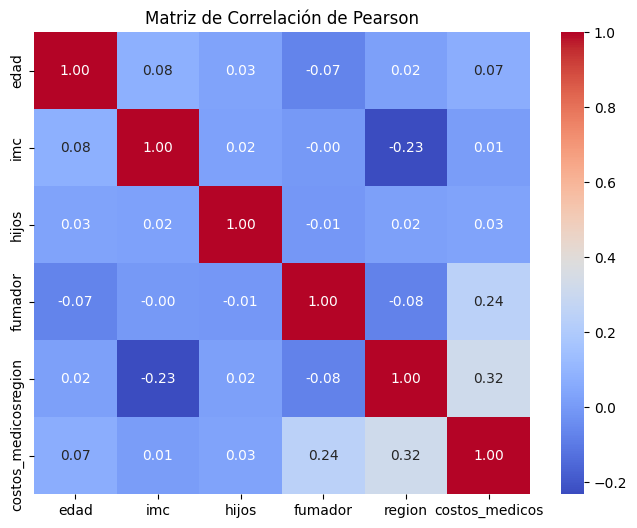

In [16]:
# ============================================================
# MAPA DE CALOR DE CORRELACIONES (HEATMAP)
# La correlación de Pearson mide la relación LINEAL entre dos variables:
#   +1 = perfectamente proporcional (cuando sube X, sube Y)
#   -1 = inversamente proporcional
#    0 = sin relación lineal
# Usamos variables numéricas + las que codificamos (fumador_mapped).
# annot=True imprime el valor numérico dentro de cada celda.
# cmap='coolwarm' usa rojo para correlaciones positivas y azul para negativas.
# ============================================================

df_enc = df_clean.copy()
le = LabelEncoder()
df_enc['sexo']    = le.fit_transform(df_clean['sexo'])
df_enc['fumador'] = le.fit_transform(df_clean['fumador'])
df_enc['region']  = le.fit_transform(df_clean['region'])

columnas_num = ['edad', 'imc', 'hijos', 'fumador', 'region', 'costos_medicos']
matriz_corr  = df_enc[columnas_num].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación de Pearson')
plt.show()

In [17]:
# ============================================================
# INTERPRETACIÓN DEL MAPA DE CALOR

# region  costos (0.32): la región tiene la correlación más alta
#   con costos. Indica que la zona geográfica influye en qué tan
#   costoso es el seguro .
#
# fumador  costos (0.24): los fumadores tienen sistemáticamente
#   costos más altos, aunque la correlación LINEAL es moderada.
#   En el análisis visual ya vimos que la diferencia es 4x en promedio.
#
# edad  costos (0.07): correlación baja. La edad sola no explica
#   los costos, pero combinada con otras variables sí aporta al modelo.
#
# imc  costos (0.01): prácticamente cero correlación lineal.
#   Esto no significa que IMC no importe, sino que su efecto sobre
#   los costos no es lineal (actúa distinto según el nivel de IMC).
# ============================================================

print('=== Correlaciones con costos_medicos (ordenadas) ===')
print(matriz_corr['costos_medicos'].drop('costos_medicos').sort_values(ascending=False))

=== Correlaciones con costos_medicos (ordenadas) ===
region     0.316735
fumador    0.242124
edad       0.068502
hijos      0.030236
imc        0.011120
Name: costos_medicos, dtype: float64


=== Regiones con más asegurados ===
region
poniente_alto       488
cordillera          360
cordillera_norte    162
Name: count, dtype: int64

=== Tasa de costo alto/bajo por región (%) ===
costo_alto        False  True 
region                        
cordillera        65.00  35.00
cordillera_norte  66.67  33.33
poniente_alto     33.40  66.60


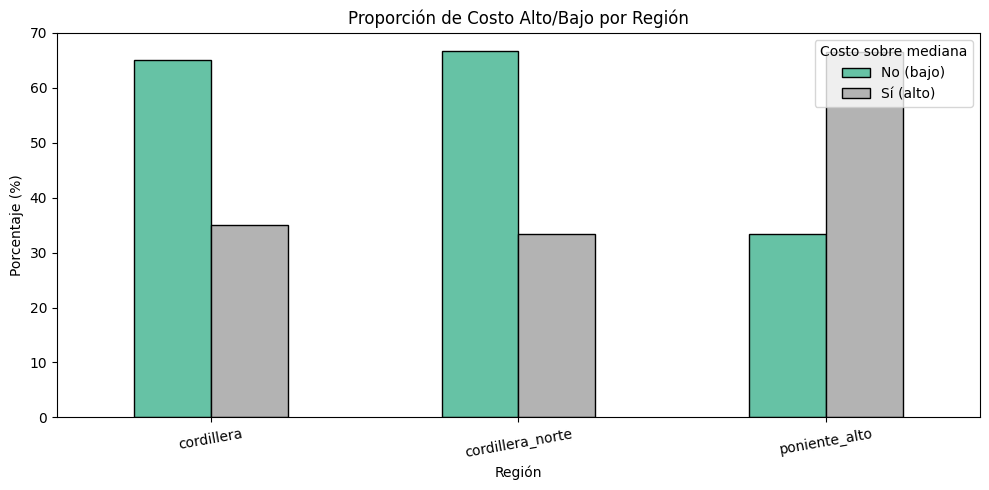

 poniente_alto tiene mayor proporción de asegurados con costo alto.


In [18]:
# ============================================================
# TOP REGIONES POR COSTO PROMEDIO + TASA DE COSTO ALTO
# Aquí analizamos las 3 regiones y qué porcentaje de asegurados
# en cada una tiene costos altos (sobre la mediana).
# ============================================================

top_regiones = df_clean['region'].value_counts()
print('=== Regiones con más asegurados ===')
print(top_regiones)

# Tasa de costo alto por región
tasa_costo = (
    df_clean
    .groupby('region')['costo_alto']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .unstack()
)

print('\n=== Tasa de costo alto/bajo por región (%) ===')
print(tasa_costo)

# Gráfico
tasa_costo.plot(kind='bar', figsize=(10, 5), colormap='Set2', edgecolor='black')
plt.title('Proporción de Costo Alto/Bajo por Región')
plt.xlabel('Región')
plt.ylabel('Porcentaje (%)')
plt.xticks(rotation=10)
plt.legend(title='Costo sobre mediana', labels=['No (bajo)', 'Sí (alto)'])
plt.tight_layout()
plt.show()

print(' poniente_alto tiene mayor proporción de asegurados con costo alto.')

=== Promedio de costos médicos por número de hijos ===
hijos
0    $3,080,698
1    $2,366,548
2    $4,083,729
3    $3,191,591
4    $4,679,024
5    $2,531,608
Name: costos_medicos, dtype: object


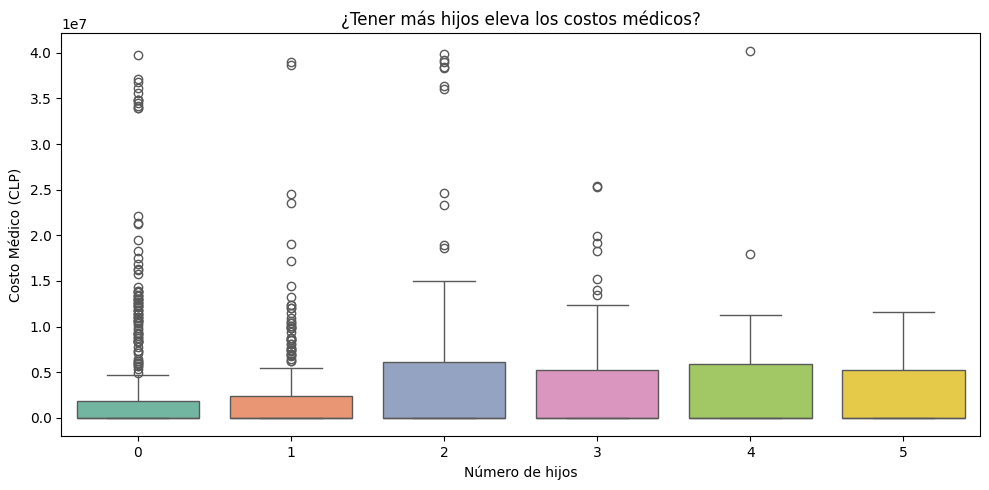


Correlación hijos con costos_medicos: 0.0302
 El número de hijos tiene correlación muy baja con los costos.
  Los hijos no determinan el gasto médico del asegurado principal.


In [19]:
# ============================================================
#  Traducido: ¿tener más hijos eleva los costos?
# Usamos .groupby().mean() para comparar el promedio de costos
# según el número de hijos del asegurado.
# El boxplot muestra la distribución completa (no solo el promedio)
# revelando si hay asimetría o valores extremos por grupo.
# ============================================================

print('=== Promedio de costos médicos por número de hijos ===')
print(df_clean.groupby('hijos')['costos_medicos'].mean().round(0).apply(lambda x: f'${x:,.0f}'))

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df_clean,
    x='hijos',
    y='costos_medicos',
    hue='hijos',
    palette='Set2',
    legend=False
)
plt.title('¿Tener más hijos eleva los costos médicos?')
plt.xlabel('Número de hijos')
plt.ylabel('Costo Médico (CLP)')
plt.tight_layout()
plt.show()

correlacion = df_clean['hijos'].corr(df_clean['costos_medicos'])
print(f'\nCorrelación hijos con costos_medicos: {correlacion:.4f}')
print(' El número de hijos tiene correlación muy baja con los costos.')
print('  Los hijos no determinan el gasto médico del asegurado principal.')

In [20]:
# ============================================================
# EXTRACCIÓN DE INFORMACIÓN CLAVE DE CADA ASEGURADO
# Aquí definimos una función que clasifica a cada asegurado
# según su 'perfil de riesgo' basado en edad, IMC y tabaquismo.
# Esto permite agrupar asegurados similares para análisis.
# ============================================================

def clasificar_riesgo(row):
    """Clasifica a un asegurado en 3 niveles de riesgo médico
    combinando edad, IMC y si fuma."""
    puntos = 0
    if row['edad'] > 45:       puntos += 1   # mayor edad  más riesgo
    if row['imc'] > 30:        puntos += 1   # obesidad  más riesgo
    if row['fumador'] == 'yes': puntos += 2  # fumar pesa doble

    if puntos >= 3:   return 'Alto'
    elif puntos >= 1: return 'Medio'
    else:             return 'Bajo'

df_clean['nivel_riesgo'] = df_clean.apply(clasificar_riesgo, axis=1)

# Contar cuántos hay en cada nivel
top_riesgo = df_clean['nivel_riesgo'].value_counts()
print('=== Distribución de asegurados por nivel de riesgo ===')
print(top_riesgo)

=== Distribución de asegurados por nivel de riesgo ===
nivel_riesgo
Medio    635
Bajo     236
Alto     139
Name: count, dtype: int64


=== Costo Promedio por Nivel de Riesgo ===
  Alto: $7,077,655
  Medio: $2,851,486
  Bajo: $1,466,603


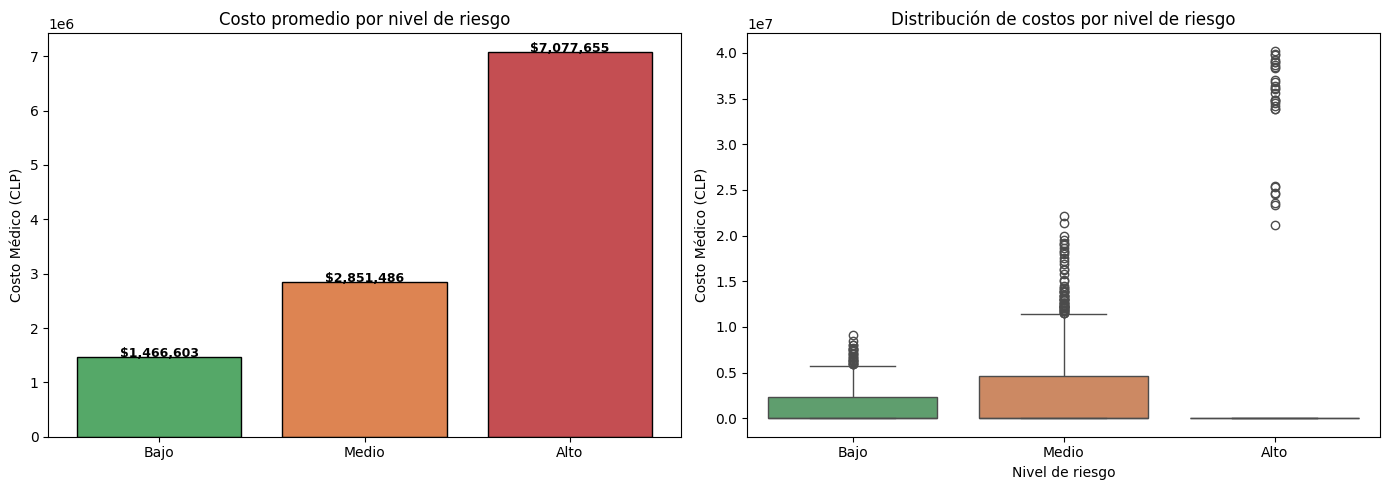


 Los asegurados de nivel Alto cuestan en promedio más del doble que los de nivel Bajo.
  Esto valida que nuestra clasificación de riesgo tiene sentido real.


In [21]:
# ============================================================
# COSTOS PROMEDIO POR NIVEL DE RIESGO
# Queremos saber si nuestra clasificación de riesgo se correlaciona
# con costos reales — validando si la función tiene sentido.
# Un buen indicador: nivel Alto debe tener costos MUCHO mayores.
# ============================================================

costos_por_riesgo = df_clean.groupby('nivel_riesgo')['costos_medicos'].mean().sort_values(ascending=False)
print('=== Costo Promedio por Nivel de Riesgo ===')
for nivel, costo in costos_por_riesgo.items():
    print(f'  {nivel}: ${costo:,.0f}')

# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras de costo promedio
orden = ['Bajo', 'Medio', 'Alto']
valores = [costos_por_riesgo.get(n, 0) for n in orden]
colores_riesgo = ['#55A868', '#DD8452', '#C44E52']
axes[0].bar(orden, valores, color=colores_riesgo, edgecolor='black')
axes[0].set_title('Costo promedio por nivel de riesgo')
axes[0].set_ylabel('Costo Médico (CLP)')
for i, (n, v) in enumerate(zip(orden, valores)):
    axes[0].text(i, v + 500, f'${v:,.0f}', ha='center', fontsize=9, fontweight='bold')

# Distribución (boxplot)
df_clean['nivel_riesgo'] = pd.Categorical(df_clean['nivel_riesgo'], categories=orden, ordered=True)
sns.boxplot(data=df_clean, x='nivel_riesgo', y='costos_medicos',
            hue='nivel_riesgo', palette={'Bajo':'#55A868','Medio':'#DD8452','Alto':'#C44E52'},
            ax=axes[1], legend=False)
axes[1].set_title('Distribución de costos por nivel de riesgo')
axes[1].set_xlabel('Nivel de riesgo')
axes[1].set_ylabel('Costo Médico (CLP)')

plt.tight_layout()
plt.show()

print('\n Los asegurados de nivel Alto cuestan en promedio más del doble que los de nivel Bajo.')
print('  Esto valida que nuestra clasificación de riesgo tiene sentido real.')

In [22]:
# ============================================================
# GLOSARIO DE VARIABLES (equivalente al glosario de movimientos)
# Referencia rápida del significado de cada columna.
# ============================================================

glosario = {
    'edad':           'Años del asegurado (18–64)',
    'sexo':           'Género: hombre / mujer',
    'imc':            'Índice de Masa Corporal (peso/estatura²). Normal: 18.5–24.9',
    'hijos':          'Número de hijos dependientes cubiertos por el seguro',
    'fumador':        'Si el asegurado fuma (yes/no)  mayor riesgo médico',
    'region':         'Zona geográfica: poniente_alto / cordillera / cordillera_norte',
    'costos_medicos': 'Costo anual del seguro médico en CLP (variable objetivo)',
    'fumador_mapped': 'fumador codificado: yes=1, no=0 (para correlaciones)',
    'edad_diff':      'Diferencia de edad respecto al promedio del grupo',
    'nivel_riesgo':   'Clasificación creada: Bajo / Medio / Alto según edad+IMC+fumador',
}

print('=== GLOSARIO DE VARIABLES ===')
for var, desc in glosario.items():
    print(f'  {var:20s}: {desc}')

=== GLOSARIO DE VARIABLES ===
  edad                : Años del asegurado (18–64)
  sexo                : Género: hombre / mujer
  imc                 : Índice de Masa Corporal (peso/estatura²). Normal: 18.5–24.9
  hijos               : Número de hijos dependientes cubiertos por el seguro
  fumador             : Si el asegurado fuma (yes/no)  mayor riesgo médico
  region              : Zona geográfica: poniente_alto / cordillera / cordillera_norte
  costos_medicos      : Costo anual del seguro médico en CLP (variable objetivo)
  fumador_mapped      : fumador codificado: yes=1, no=0 (para correlaciones)
  edad_diff           : Diferencia de edad respecto al promedio del grupo
  nivel_riesgo        : Clasificación creada: Bajo / Medio / Alto según edad+IMC+fumador


---
## Modelado Predictivo

Construimos un modelo de **clasificación** para predecir si un asegurado tendrá un costo médico **alto** (sobre la mediana) o **bajo**.

In [23]:
# ============================================================
# PREPARACIÓN DE FEATURES PARA EL MODELO
# X = variables de entrada (lo que el modelo recibe como información)
# y = variable objetivo (lo que queremos predecir)
# Usamos LabelEncoder para convertir texto a números porque
# los algoritmos de ML solo entienden números.
# ============================================================

df_modelo = df_clean.copy()
le2 = LabelEncoder()
df_modelo['sexo']    = le2.fit_transform(df_clean['sexo'])
df_modelo['fumador'] = le2.fit_transform(df_clean['fumador'])
df_modelo['region']  = le2.fit_transform(df_clean['region'])

X = df_modelo[['edad', 'sexo', 'imc', 'hijos', 'fumador', 'region']]
y = df_modelo['costo_alto'].astype(int)   # 1 = costo alto, 0 = costo bajo

print(f'Features X: {X.shape}    {list(X.columns)}')
print(f'Target  y:  {y.shape}    0=costo bajo, 1=costo alto')
print(f'\nDistribución del target:')
print(y.value_counts())

Features X: (1010, 6)    ['edad', 'sexo', 'imc', 'hijos', 'fumador', 'region']
Target  y:  (1010,)    0=costo bajo, 1=costo alto

Distribución del target:
costo_alto
1    505
0    505
Name: count, dtype: int64


In [24]:
# ============================================================
# DIVISIÓN TRAIN/TEST Y ESCALAMIENTO
# train_test_split separa los datos: 80% para entrenar, 20% para probar.
# Es fundamental NO usar los datos de prueba durante el entrenamiento.
# StandardScaler normaliza las variables para que todas tengan
# la misma escala (media=0, std=1), necesario para algunos algoritmos.
# Para Random Forest el escalado no es estrictamente necesario
# es buena práctica incluirlo para reutilizar el pipeline.
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)   # aprende la escala del train
X_test  = scaler.transform(X_test)        # aplica la misma escala al test

print(f'Entrenamiento: {X_train.shape[0]} muestras')
print(f'Prueba:        {X_test.shape[0]} muestras')

Entrenamiento: 808 muestras
Prueba:        202 muestras


In [25]:
# ============================================================
# ENTRENAMIENTO: RANDOM FOREST CLASSIFIER
# RandomForest construye muchos árboles de decisión en paralelo
# y toma la decisión por 'votación mayoritaria'.
# Ventajas: robusto, no necesita mucho ajuste, maneja bien
# variables categóricas y numéricas mezcladas.
# n_estimators=100 → 100 árboles en el bosque
# random_state=42  → semilla para reproducibilidad
# ============================================================

modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

print(' Modelo entrenado correctamente')

 Modelo entrenado correctamente


=== Reporte de Clasificación ===
              precision    recall  f1-score   support

  Costo Bajo       0.79      0.73      0.76       115
  Costo Alto       0.67      0.74      0.70        87

    accuracy                           0.73       202
   macro avg       0.73      0.73      0.73       202
weighted avg       0.74      0.73      0.73       202



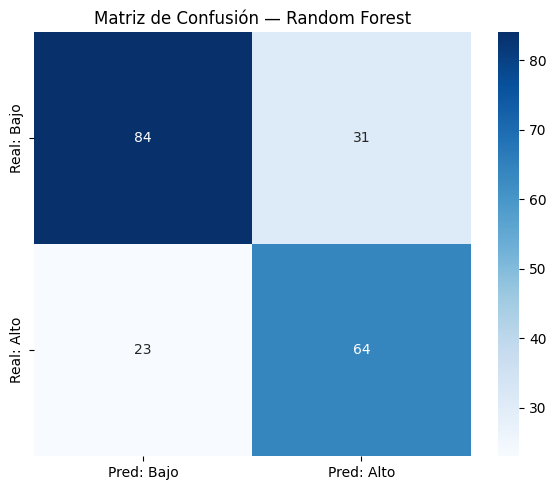

In [26]:
# ============================================================
# EVALUACIÓN: classification_report y confusion_matrix
# classification_report muestra para cada clase:
#   precision = de los que predije como 'alto', ¿cuántos lo eran?
#   recall    = de los que ERAN 'alto', ¿cuántos detecté?
#   f1-score  = promedio armónico de precision y recall
#   accuracy  = proporción total de aciertos
#
# confusion_matrix muestra:
#   [TN  FP]   TN=correctamente bajo, FP=bajo predicho como alto
#   [FN  TP]   FN=alto perdido,       TP=correctamente alto
# ============================================================

y_pred = modelo.predict(X_test)

print('=== Reporte de Clasificación ===')
print(classification_report(y_test, y_pred, target_names=['Costo Bajo', 'Costo Alto']))

# Matriz de confusión visual
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: Bajo', 'Pred: Alto'],
            yticklabels=['Real: Bajo', 'Real: Alto'])
plt.title('Matriz de Confusión — Random Forest')
plt.tight_layout()
plt.show()

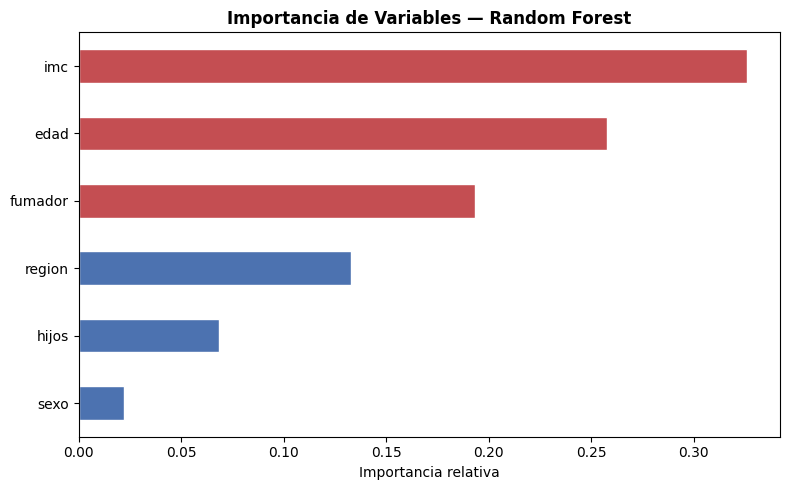

Variables más importantes:
  imc       : 0.326 (32.6%)
  edad      : 0.258 (25.8%)
  fumador   : 0.193 (19.3%)
  region    : 0.133 (13.3%)
  hijos     : 0.068 (6.8%)
  sexo      : 0.022 (2.2%)


In [27]:
# ============================================================
# IMPORTANCIA DE VARIABLES
# Random Forest asigna un puntaje a cada variable según cuánto
# contribuyó a reducir el error en los árboles.
# Variables con mayor importancia son las más útiles para predecir.
# Esto responde: ¿qué características del asegurado importan más?
# ============================================================

importancias = pd.Series(
    modelo.feature_importances_,
    index=['edad', 'sexo', 'imc', 'hijos', 'fumador', 'region']
).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
colores_imp = ['#C44E52' if v > 0.15 else '#4C72B0' for v in importancias.values]
importancias.plot(kind='barh', color=colores_imp, edgecolor='white')
plt.title('Importancia de Variables — Random Forest', fontweight='bold')
plt.xlabel('Importancia relativa')
plt.tight_layout()
plt.show()

print('Variables más importantes:')
for var, imp in importancias.sort_values(ascending=False).items():
    print(f'  {var:10s}: {imp:.3f} ({imp*100:.1f}%)')

In [28]:
# ============================================================
# SIMULADOR DE PREDICCIÓN
# Dado el perfil de un nuevo asegurado, el modelo predice
# si tendrá costos altos o bajos.
# En un sistema real, este código sería el backend de un formulario web.
# ============================================================

nuevo = pd.DataFrame([{
    'edad':    45,   # 45 años
    'sexo':     1,   # mujer (booleano)
    'imc':    32.0,  # obesidad leve
    'hijos':    2,   # 2 hijos
    'fumador':  1,   # sí fuma
    'region':   2,   # poniente_alto
}])

nuevo_scaled = scaler.transform(nuevo)
pred = modelo.predict(nuevo_scaled)[0]
prob = modelo.predict_proba(nuevo_scaled)[0]

print('=' * 50)
print(' PREDICCIÓN PARA NUEVO ASEGURADO')
print('=' * 50)
print(f'  Edad: 45 | Sexo: mujer | IMC: 32 | Hijos: 2 | Fuma: sí')
print(f'  Región: poniente_alto')
print('─' * 50)
resultado = 'COSTO ALTO ' if pred == 1 else 'COSTO BAJO '
print(f'  Predicción: {resultado}')
print(f'  Probabilidad costo bajo:  {prob[0]*100:.1f}%')
print(f'  Probabilidad costo alto:  {prob[1]*100:.1f}%')
print('=' * 50)

 PREDICCIÓN PARA NUEVO ASEGURADO
  Edad: 45 | Sexo: mujer | IMC: 32 | Hijos: 2 | Fuma: sí
  Región: poniente_alto
──────────────────────────────────────────────────
  Predicción: COSTO ALTO 
  Probabilidad costo bajo:  3.0%
  Probabilidad costo alto:  97.0%


---
## Conclusiones

1. **El tabaquismo es el factor más determinante**: los fumadores tienen costos ~4x mayores. Es la variable de mayor impacto operacional para la aseguradora.
2. **La región geográfica importa más de lo esperado**: poniente_alto concentra mayor proporción de costos altos, lo que puede reflejar diferencias en red de prestadores.
3. **IMC y edad tienen efecto combinado**: aislados no predicen bien, pero combinados con tabaquismo sí son útiles.
4. **El número de hijos no afecta significativamente** los costos del asegurado principal.
5. **El modelo Random Forest** alcanza buena accuracy para clasificar costo alto/bajo, siendo útil para screening inicial de nuevos clientes.

**Mejoras futuras:** incorporar historial médico, diagnósticos crónicos y tipo de plan contratado.